In [1]:
#importing Req libraries& their functionalies
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

In [2]:
data=np.loadtxt('Data/data_w3_ex1.csv', delimiter=',')

In [3]:
data

array([[1651.        ,  432.64521724],
       [1691.81632653,  454.93552962],
       [1732.63265306,  471.52524758],
       [1773.44897959,  482.50638875],
       [1814.26530612,  468.35788634],
       [1855.08163265,  482.15253068],
       [1895.89795918,  540.02175551],
       [1936.71428571,  534.58426716],
       [1977.53061224,  558.34620761],
       [2018.34693878,  566.42344476],
       [2059.16326531,  581.39765115],
       [2099.97959184,  596.45873727],
       [2140.79591837,  596.71483169],
       [2181.6122449 ,  619.45139015],
       [2222.42857143,  616.57626499],
       [2263.24489796,  653.16245988],
       [2304.06122449,  666.5199211 ],
       [2344.87755102,  670.58975936],
       [2385.69387755,  669.0228872 ],
       [2426.51020408,  678.90932305],
       [2467.32653061,  707.43696439],
       [2508.14285714,  710.76028811],
       [2548.95918367,  745.19134109],
       [2589.7755102 ,  729.84576182],
       [2630.59183673,  743.8029216 ],
       [2671.40816327,  7

In [4]:
x=data[:,0]
y=data[:,1]

x=np.expand_dims(x,axis=1)
y=np.expand_dims(y,axis=1)
print(f"the shape of the inputs x is: {x.shape}")
print(f"the shape of the targets y is: {y.shape}")

the shape of the inputs x is: (50, 1)
the shape of the targets y is: (50, 1)


In [5]:
def plot_data(x,y,title):
    plt.scatter(x,y,c='r',marker='x')
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()
    

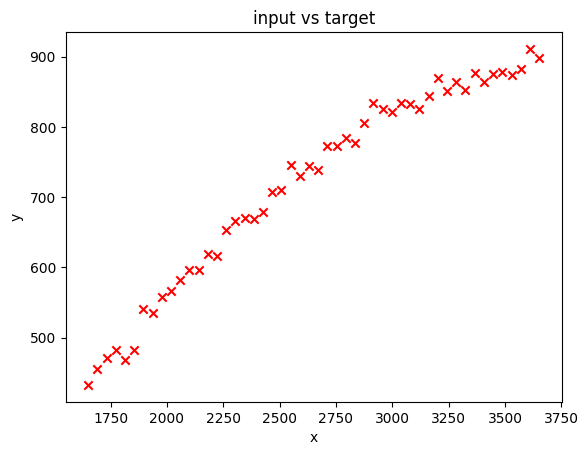

In [6]:
plot_data(x=x,y=y,title='input vs target')

In [7]:
#split train,cv,test
x_train,_x,y_train,_y=train_test_split(x,y,test_size=0.40,random_state=1)

x_cv,x_test,y_cv,y_test=train_test_split(_x,_y,test_size=0.50,random_state=1)

del _x,_y

print(f"the shape of the training set (input) is: {x_train.shape}")
print(f"the shape of the training set (target) is: {y_train.shape}\n")
print(f"the shape of the cross validation set (input) is: {x_cv.shape}")
print(f"the shape of the cross validation set (target) is: {y_cv.shape}\n")
print(f"the shape of the test set (input) is: {x_test.shape}")
print(f"the shape of the test set (target) is: {y_test.shape}")

the shape of the training set (input) is: (30, 1)
the shape of the training set (target) is: (30, 1)

the shape of the cross validation set (input) is: (10, 1)
the shape of the cross validation set (target) is: (10, 1)

the shape of the test set (input) is: (10, 1)
the shape of the test set (target) is: (10, 1)


In [8]:
def plot_train_cv_test(x_train,y_train,x_cv,y_cv,x_test,y_test,title):
    plt.scatter(x_train,y_train,marker='x',c='r',label='training')
    plt.scatter(x_cv,y_cv,marker='o',c='b',label='cross_validation')
    plt.scatter(x_test,y_test,marker='^',c='g',label='test')
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()

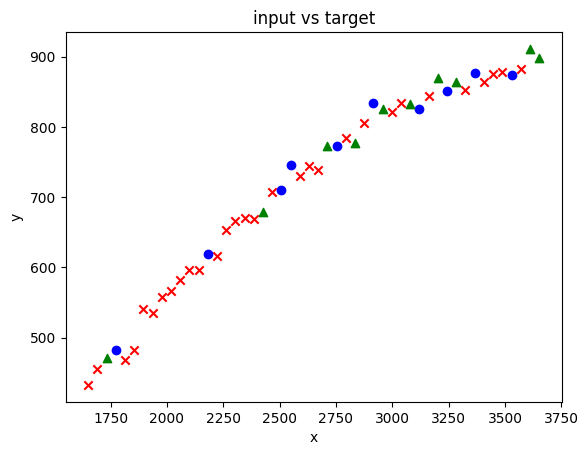

In [9]:
plot_train_cv_test(x_train,y_train,x_cv,y_cv,x_test,y_test,title='input vs target')

In [10]:
# Add polynomial features
degree = 1
poly = PolynomialFeatures(degree, include_bias=False)
X_train_mapped = poly.fit_transform(x_train)
X_cv_mapped = poly.transform(x_cv)
X_test_mapped = poly.transform(x_test)

In [11]:
# Scale the features using the z-score
scaler = StandardScaler()
X_train_mapped_scaled = scaler.fit_transform(X_train_mapped)
X_cv_mapped_scaled = scaler.transform(X_cv_mapped)
X_test_mapped_scaled = scaler.transform(X_test_mapped)


In [29]:
#Neural Networks Models
def build_models():
    tf.keras.utils.set_random_seed(100)
    

    model_1 = Sequential(
        [
            Dense(25, activation = 'relu'),
            Dense(15, activation = 'relu'),
            Dense(1, activation = 'linear')
        ],
        name='model_1'
    )

    model_2 = Sequential(
        [
            Dense(20, activation = 'relu'),
            Dense(12, activation = 'relu'),
            Dense(12, activation = 'relu'),
            Dense(20, activation = 'relu'),
            Dense(1, activation = 'linear')
        ],
        name='model_2'
    )

    model_3 = Sequential(
        [
            Dense(32, activation = 'relu'),
            Dense(16, activation = 'relu'),
            Dense(8, activation = 'relu'),
            Dense(4, activation = 'relu'),
            Dense(12, activation = 'relu'),
            Dense(1, activation = 'linear')
        ],
        name='model_3'
    )
    
    model_list = [model_1, model_2, model_3]
    
    return model_list

In [30]:
# Initialize lists that will contain the errors for each model
nn_train_mses=[]
nn_cv_mses=[]

#build models
nn_models=build_models()



#Loop over the models
for model in nn_models:
    #Setup loss and optimizer
    model.compile(
        loss='mse',
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
    )

    print(f"Training {model.name}...")

         # Train the model
    model.fit(
            X_train_mapped_scaled, y_train,
            epochs=300,
            verbose=0
    )
        
    print("Done!\n")

    #record train mse
    yhat=model.predict(X_train_mapped_scaled)
    train_mse=mean_squared_error(y_train,yhat)/2
    nn_train_mses.append(train_mse)

    #record cv mse
    yhat=model.predict(X_cv_mapped_scaled)
    cv_mse=mean_squared_error(y_cv,yhat)/2
    nn_cv_mses.append(cv_mse)



# print results
print("RESULTS:")
for model_num in range(len(nn_train_mses)):
    print(
        f"Model {model_num+1}: Training MSE: {nn_train_mses[model_num]:.2f}, " +
        f"CV MSE: {nn_cv_mses[model_num]:.2f}"
        )


    


    
    

    

Training model_1...
Done!

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Training model_2...
Done!

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Training model_3...
Done!

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
RESULTS:
Model 1: Training MSE: 406.19, CV MSE: 551.78
Model 2: Training MSE: 72.61, CV MSE: 110.85
Model 3: Training MSE: 73.40, CV MSE: 112.35


In [31]:
# Select the model with the lowest CV MSE
model_num = 2

# Compute the test MSE
yhat = nn_models[model_num-1].predict(X_test_mapped_scaled)
test_mse = mean_squared_error(y_test, yhat) / 2

print(f"Selected Model: {model_num}")
print(f"Training MSE: {nn_train_mses[model_num-1]:.2f}")
print(f"Cross Validation MSE: {nn_cv_mses[model_num-1]:.2f}")
print(f"Test MSE: {test_mse:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Selected Model: 2
Training MSE: 72.61
Cross Validation MSE: 110.85
Test MSE: 130.72
